# HySwash: Surrogate Modeling and Long-Term Reconstruction

In the previous notebook, we used SWASH to simulate a representative set of
offshore wave conditions selected with MDA.

In this notebook, we will use those simulations to train **surrogate models**
that reproduce the nearshore wave transformation at a fraction of the
computational cost.

We will then apply these surrogate models to the historical forcing of 2020
(waves from **BinWaves** and water levels from a **tide gauge**) to reconstruct
the corresponding **nearshore wave climate**: mean setup, infragravity waves
and runup.

In [2]:
import os
import os.path as op
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import xarray as xr

sys.path.insert(0, "..") 

from utils.plotting import (
    plot_depthfile,
    plot_scatters_colored,
    plot_scatters_Tp,
    steepness_to_Tp,
)

## Load the SWASH simulations

We will start by loading the HySwash configuration, the MDA model, and the
postprocessed SWASH simulations generated in the previous notebook.

These simulations will provide the **training data** for the surrogate models.

In [3]:
root_dir = os.getcwd()
output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")

In [4]:
from bluemath_tk.core.io import load_model

mda = load_model(op.join(export_dir, "mda_model.pkl"))

depth_file = op.join(templates_dir, "depth.bot")
depth_array = np.loadtxt(depth_file)

postprocessed_output = xr.open_dataset(
    op.join(output_dir, "output_postprocessed.nc")
)

postprocessed_output

<xarray.Dataset> Size: 528kB
Dimensions:   (case_num: 10, Tsec: 451, Xp: 1001)
Coordinates:
  * case_num  (case_num) int64 80B 0 1 2 3 4 5 6 7 8 9
  * Tsec      (Tsec) int64 4kB 0 1 2 3 4 5 6 7 ... 444 445 446 447 448 449 450
  * Xp        (Xp) int64 8kB 0 1 2 3 4 5 6 7 ... 994 995 996 997 998 999 1000
Data variables:
    Ru2       (case_num) float64 80B ...
    Runlev    (case_num, Tsec) float64 36kB ...
    Msetup    (case_num, Xp) float64 80kB ...
    Hrms      (case_num, Xp) float64 80kB ...
    Hs        (case_num, Xp) float64 80kB ...
    Hss       (case_num, Xp) float64 80kB ...
    Hig       (case_num, Xp) float64 80kB ...
    Hvlf      (case_num, Xp) float64 80kB ...

## Build the surrogate model

The SWASH simulations provide spatially distributed results along the
cross-shore profile for a limited number of representative offshore conditions.

Our goal is to predict these spatial fields for **new offshore conditions**
without running SWASH again.

HySwash combines two techniques for this purpose:

1. **Principal Component Analysis (PCA)** reduces each spatial SWASH output to a
   small number of principal components.
2. **Radial Basis Functions (RBF)** interpolate the principal components as a
   function of the offshore forcing conditions.

For a new combination of offshore conditions, the RBF model predicts the
principal components, and the PCA transformation is inverted to reconstruct
the complete cross-shore field.

**SWASH simulations → PCA → RBF → predicted PCs → spatial reconstruction**

### Principal Component Analysis (PCA)

The postprocessed SWASH outputs contain one value at each cross-shore location.
Instead of building an independent surrogate model for every location, we use
PCA to represent these spatial fields with a smaller number of variables.

PCA identifies the dominant spatial patterns in the SWASH simulations and
represents each simulation through its corresponding **principal component
scores (PCs)**.

By retaining only the components that explain most of the variance, we reduce
the dimensionality of the problem while preserving the dominant spatial
variability.
We build one PCA for each cross-shore variable we want to reconstruct:
the **mean setup** (`Msetup`) and the **infragravity wave height** (`Hig`).


In [5]:
# Cross-shore variables to reconstruct
spatial_vars = ["Msetup", "Hig"]

# SWASH cases that were postprocessed successfully (training data)
train_cases = mda.centroids.iloc[postprocessed_output["case_num"].values]


In [6]:
from bluemath_tk.datamining.pca import PCA

pcas = {}
for var in spatial_vars:
    pcas[var] = PCA()
    pcas[var].fit_transform(
        data=postprocessed_output,
        vars_to_stack=[var],
        coords_to_stack=["Xp"],
        pca_dim_for_rows="case_num",
        value_to_replace_nans={var: 0.0},
        # keep every point that is wet in at least one SWASH case (the swash
        # zone is dry in some cases); dry values are filled with 0
        nan_threshold_to_drop={var: 0.0},
    )
    pcas[var].save_model(
        model_path=op.join(export_dir, f"pca_model_{var}.pkl"),
    )


2026-10-02 17:58:15,610 - PCA - WARNING - Using 917 out of 1001 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-10-02 17:58:15,613 - PCA - WARNING - Data contains NaNs.
2026-10-02 17:58:15,771 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!
2026-10-02 17:58:15,800 - PCA - WARNING - Using 917 out of 1001 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-10-02 17:58:15,803 - PCA - WARNING - Data contains NaNs.
2026-10-02 17:58:15,829 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


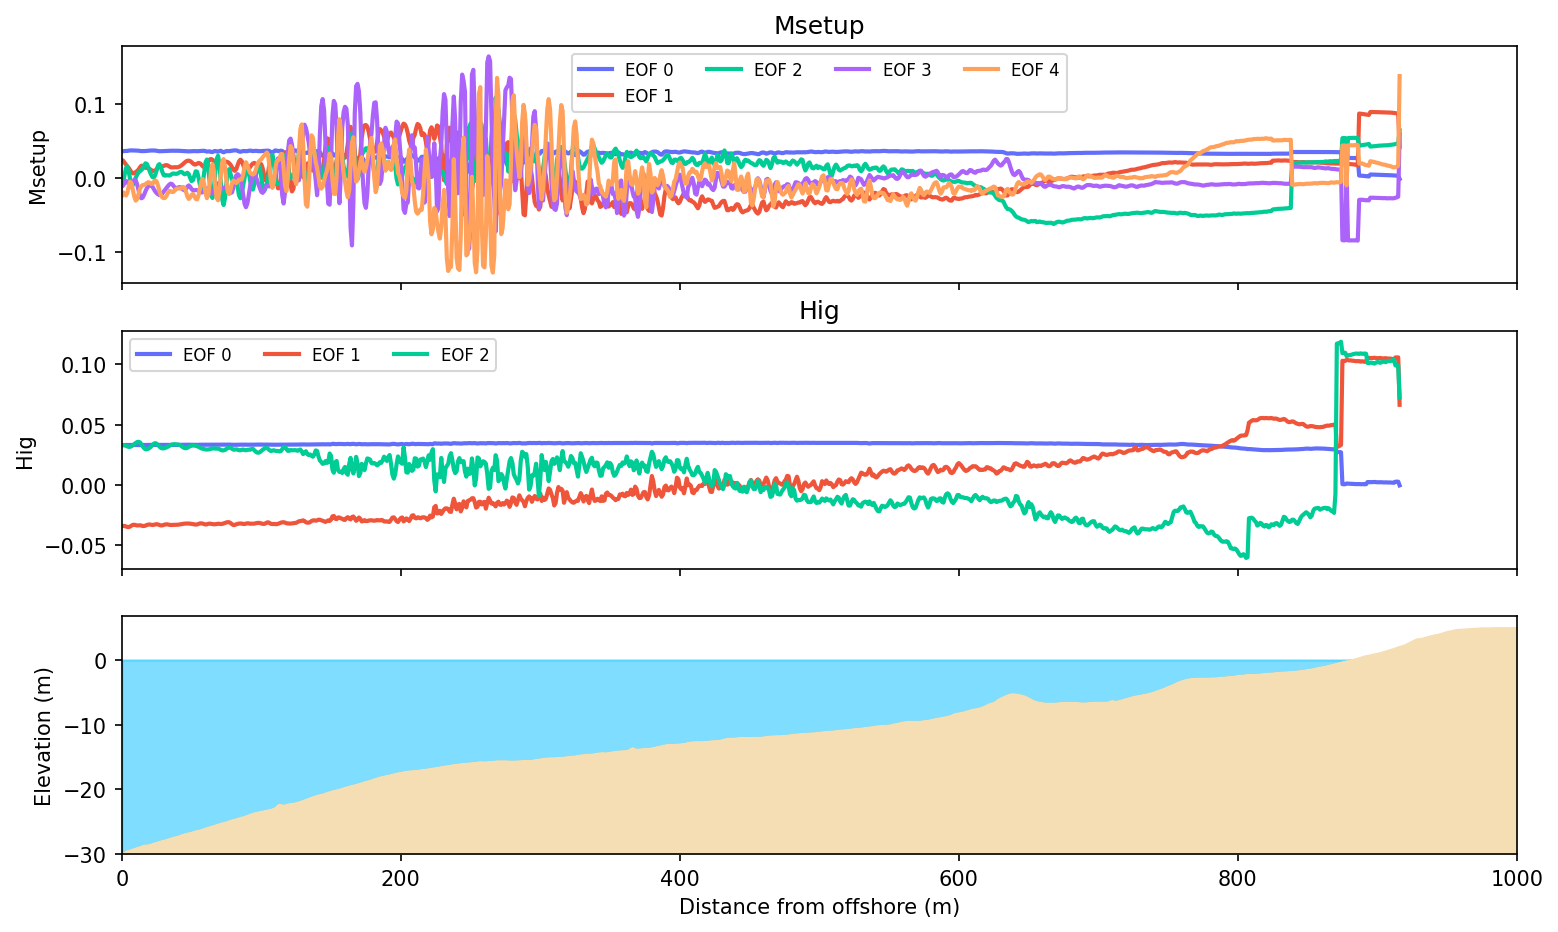

In [7]:
fig, axs = plt.subplots(
    len(spatial_vars) + 1, 1, figsize=(12, 7), sharex=True, dpi=150
)
plot_depthfile(depth_array, ax=axs[-1])

for ax, var in zip(axs, spatial_vars):
    for component in pcas[var].eofs.n_component.values:
        pcas[var].eofs.isel(n_component=component)[var].plot(
            ax=ax,
            color=px.colors.qualitative.Plotly[component % 10],
            lw=2,
            label=f"EOF {component}",
        )
    ax.set_title(var)
    ax.set_xlabel("")
    ax.legend(ncols=4, fontsize=8)

axs[-1].set_xlim(0, 1000)
plt.show()


### Spatial surrogate: RBF interpolation

Once the spatial fields have been represented by their principal components,
we need to relate those components to the offshore forcing conditions.

For this purpose, HySwash uses **Radial Basis Function (RBF) interpolation**.
The RBF model learns the relationship between:

**offshore forcing conditions → principal component scores**

For new offshore conditions, the RBF predicts the PCs, which can then be
transformed back through the PCA model to reconstruct the complete spatial field.

**offshore conditions → RBF → PCs → inverse PCA → spatial field**

In [8]:
from bluemath_tk.interpolation.rbf import RBF

rbfs = {}
for var in spatial_vars:
    rbfs[var] = RBF()
    rbfs[var].fit(
        subset_data=train_cases,
        target_data=pcas[var].pcs_df,
    )
    rbfs[var].save_model(
        model_path=op.join(export_dir, f"rbf_spatial_model_{var}.pkl")
    )


### Scalar surrogate: wave runup

Some SWASH outputs, such as `Ru2`, contain a **single value for each
simulation**. In this case, dimensionality reduction is not required.

The RBF can therefore be trained directly between the offshore forcing
conditions and the scalar output:

**offshore conditions → RBF → `Ru2`**

This provides a simpler surrogate-modeling strategy for scalar quantities.

In [9]:
Ru2 = pd.DataFrame(
    postprocessed_output["Ru2"].values,
    columns=["Ru2"],
)

rbf_scalar = RBF()

rbf_scalar.fit(
    subset_data=train_cases,
    target_data=Ru2,
)

rbf_scalar.save_model(
    model_path=op.join(export_dir, "rbf_scalar_model.pkl")
)

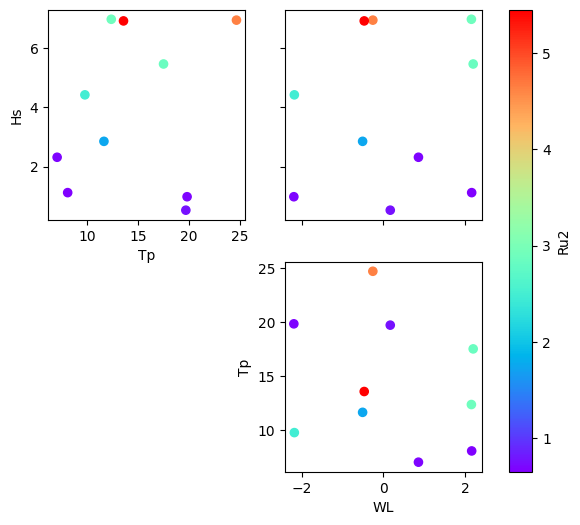

In [10]:
df_train = pd.concat([train_cases.reset_index(drop=True), Ru2], axis=1)

# The model is trained with Hs_L0, but we display the peak period Tp instead
fig, axs = plot_scatters_colored(
    steepness_to_Tp(df_train),
    variables=["Hs", "Tp", "WL"],
    color="Ru2",
    cmap="rainbow",
    s=35,
)

## Historical reconstruction

Now that the surrogate models have been trained, we can apply them to the
historical forcing without running additional SWASH simulations.

The forcing at the offshore boundary of the profile comes from:

- **Waves (`Hs`, `Hs_L0`)**: we reconstruct the waves with **BinWaves** at the
  output site closest to Newport, combining the NDBC buoy 46050 offshore
  spectra with the propagation coefficients (`kp`) computed in the BinWaves
  notebooks.
- **Water level (`WL`)**: hourly sea level at the **South Beach** tide gauge
  (GESLA), referred to its mean over the period, which is the zero of the
  profile. It includes tide and storm surge, but not wave setup, which is
  computed by SWASH.

> This is an application example: the BinWaves site is a few km away from the
> profile and shallower than its offshore boundary (30 m), but it gives a
> realistic time series of nearshore waves to force the metamodel.

> Remember: the models work with `Hs_L0`, but we show `Tp` in the figures.


In [12]:
from glob import glob

from utils.boundary_conditions import reconstruct_binwaves_point

binwaves_dir = op.join("..", "..", "additive", "binwaves")
data_dir = op.join("..", "..", "..", "..", "toolkit", "data", "outputs")

# Waves: BinWaves reconstruction at the output site closest to Newport
newport = (-124.07, 44.63)  # lon, lat
binwaves_waves = reconstruct_binwaves_point(
    offshore_spectra=xr.open_dataset(sorted(glob(op.join(data_dir, "offshore_spectra_*.nc")))[-1]),
    kp_coeffs=xr.open_dataset(op.join(binwaves_dir, "outputs", "kp_coefficients.nc")),
    swan_cases=pd.read_csv(op.join(binwaves_dir, "NEWPORT_CASES", "swan_cases.csv")),
    lon=newport[0],
    lat=newport[1],
)
site = binwaves_waves.attrs
bathy = xr.open_dataset(sorted(glob(op.join(data_dir, "GEBCO_*.nc")))[-1]).elevation
site_depth = -float(bathy.sel(lon=site["lon"], lat=site["lat"], method="nearest"))
print(
    f"BinWaves site {site['site']}: ({site['lon']:.3f}, {site['lat']:.3f}), "
    f"~{site_depth:.0f} m depth"
)

# Water level: valid tide-gauge observations, referred to their mean
gesla = xr.open_dataset(op.join(data_dir, "GESLA_South_Beach_9435380_NOAA.nc"))
t0 = binwaves_waves.time.values[0] - np.timedelta64(1, "h")
t1 = binwaves_waves.time.values[-1] + np.timedelta64(1, "h")
sea_level = gesla.sea_level.where(gesla.flag2 == 1).sel(time=slice(t0, t1))
wl = sea_level - sea_level.mean()

df_hist = pd.DataFrame(
    {
        "Hs": binwaves_waves.Hs.values,
        "Hs_L0": binwaves_waves.Hs_L0.values,
        "WL": wl.interp(time=binwaves_waves.time).values,
    },
    index=pd.DatetimeIndex(binwaves_waves.time.values, name="time"),
).dropna()

df_hist


BinWaves site 26: (-124.088, 44.571), ~10 m depth


,Hs,Hs_L0,WL
time,,,
2020-01-01 00:40:00,3.905855,0.015142,0.640307
2020-01-01 01:40:00,3.937706,0.015252,0.318973
2020-01-01 02:40:00,4.393794,0.016908,-0.093360
2020-01-01 03:40:00,4.262483,0.016395,-0.522693
2020-01-01 04:40:00,4.138848,0.015859,-0.813027
...,...,...,...
2020-12-31 19:40:00,5.283217,0.020339,1.426307
2020-12-31 20:40:00,4.975586,0.019021,1.455307
2020-12-31 21:40:00,4.648964,0.017960,1.228640


Before reconstructing, let's check that the SWASH cases (red) cover the
historical conditions (blue). The surrogate models interpolate well inside the
cloud of SWASH cases, but should not be trusted far outside it.


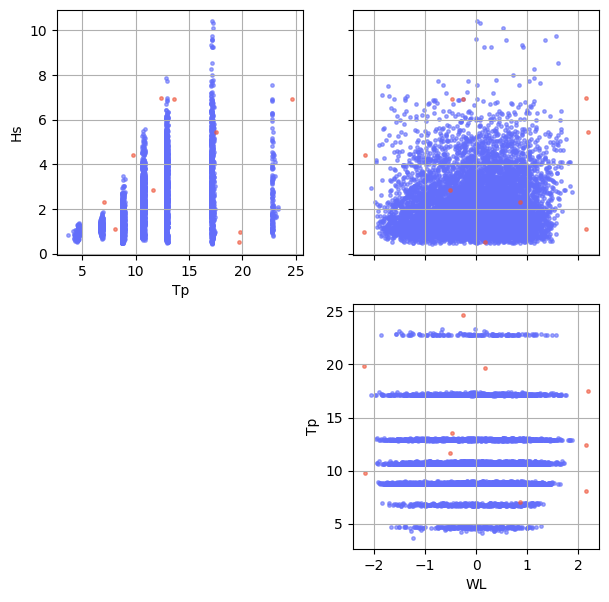

2.3% of the hours fall outside the Hs, Hs_L0 or WL range of the SWASH cases


In [13]:
fig, axes = plot_scatters_Tp(
    train_cases,
    df_hist,
    s=6,
    data_colors=px.colors.qualitative.Plotly[:2],
)
fig.set_size_inches(7, 7)
plt.show()

outside = (
    (df_hist[train_cases.columns] < train_cases.min())
    | (df_hist[train_cases.columns] > train_cases.max())
).any(axis=1)
print(f"{outside.mean():.1%} of the hours fall outside the Hs, Hs_L0 or WL range of the SWASH cases")


### 1. Scalar reconstruction: `Ru2`

For scalar outputs, the reconstruction is performed directly by the RBF model.

Hours with very short periods (local wind seas with Tp < 7 s) fall outside the
SWASH cases, so we reconstruct them with the shortest simulated period.


In [14]:
# Short wind seas (Tp < 7 s) were not simulated with SWASH (one vertical layer
# cannot resolve them at 30 m depth). We reconstruct those hours with
# Tp = 7 s, the shortest period of the SWASH cases, and flag them.
tp_min, g = 7, 9.806
max_steepness = 2 * np.pi * df_hist["Hs"] / (g * tp_min**2)
df_hist["short_period"] = df_hist["Hs_L0"] > max_steepness
print(f"{df_hist['short_period'].mean():.1%} of the hours are reconstructed with Tp = {tp_min} s")

inputs = df_hist[["Hs", "Hs_L0", "WL"]].copy()
inputs["Hs_L0"] = np.minimum(inputs["Hs_L0"], max_steepness)

df_hist["Ru2"] = rbf_scalar.predict(inputs).to_numpy().ravel()


7.1% of the hours are reconstructed with Tp = 7 s


### 2. Spatial reconstruction: `Msetup` and `Hig`

For each hour, the RBF models predict the principal components, and the PCA
transformation is inverted to recover the complete cross-shore field.

**new forcing → predicted PCs → inverse PCA → reconstructed field**

Points of the profile above the maximum runup level (`WL + Ru2`) are never
wet, so we mask them.


In [15]:
bed_level = -depth_array
runup_level = xr.DataArray(
    (df_hist["WL"] + df_hist["Ru2"]).values, dims="time", coords={"time": df_hist.index}
)

reconstructed = {}
for var in spatial_vars:
    pcs = rbfs[var].predict(inputs)
    pcs_xr = xr.DataArray(
        pcs.values,
        dims=[pcas[var].pca_dim_for_rows, "PCs"],
        coords={
            pcas[var].pca_dim_for_rows: np.arange(len(pcs)),
            "PCs": pcs.columns.values,
        },
    )
    field = (
        pcas[var]
        .inverse_transform(pcs_xr)[var]
        .rename(case_num="time")
        .assign_coords(time=df_hist.index)
    )
    wet = xr.DataArray(bed_level, dims="Xp", coords={"Xp": field.Xp}) < runup_level
    reconstructed[var] = field.where(wet)

reconstructed = xr.Dataset(reconstructed)
reconstructed["Ru2"] = xr.DataArray(df_hist["Ru2"].values, dims="time")
reconstructed["WL"] = xr.DataArray(df_hist["WL"].values, dims="time")
reconstructed.to_netcdf(op.join(export_dir, "historical_reconstruction.nc"))
reconstructed


<xarray.Dataset> Size: 138MB
Dimensions:  (Xp: 1001, time: 8602)
Coordinates:
  * Xp       (Xp) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999 1000
  * time     (time) datetime64[ns] 69kB 2020-01-01T00:40:00 ... 2020-12-31T23...
Data variables:
    Msetup   (time, Xp) float64 69MB 0.09167 0.0864 0.08165 ... nan nan nan
    Hig      (time, Xp) float64 69MB 0.8178 0.8208 0.8232 0.8219 ... nan nan nan
    Ru2      (time) float64 69kB 2.257 2.337 2.676 2.684 ... 2.565 2.577 2.513
    WL       (time) float64 69kB 0.6403 0.319 -0.09336 ... 1.229 0.777 0.1833

### 3. Explore the reconstruction

First, the time series of the offshore forcing and of the reconstructed runup.


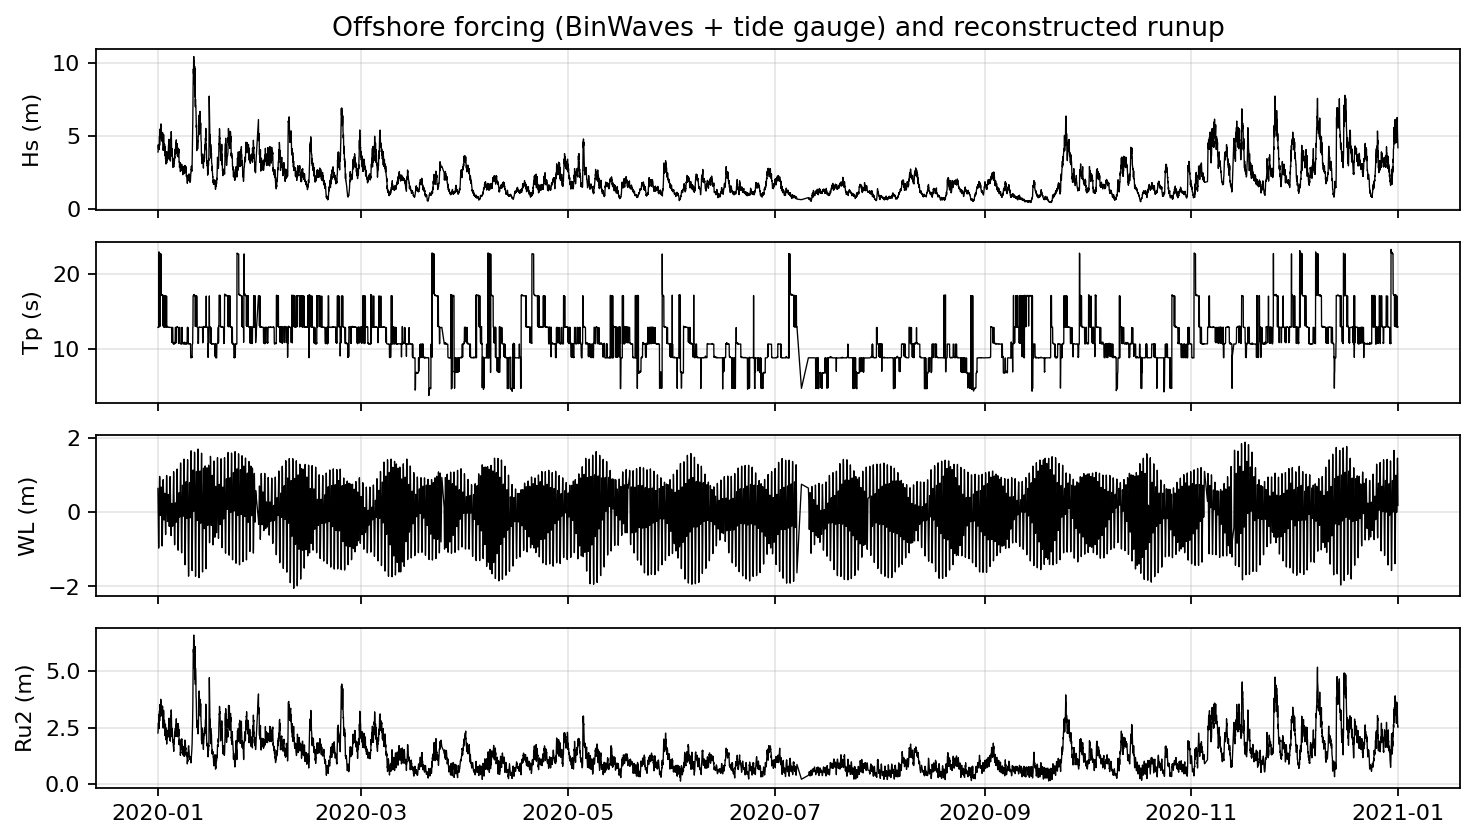

In [19]:
df_plot = steepness_to_Tp(df_hist)  # display Tp instead of Hs_L0

fig, axs = plt.subplots(4, 1, figsize=(11, 6), sharex=True, dpi=160)
labels = {"Hs": "Hs (m)", "Tp": "Tp (s)", "WL": "WL (m)", "Ru2": "Ru2 (m)"}
for ax, (var, label) in zip(axs, labels.items()):
    ax.plot(df_plot.index, df_plot[var], lw=0.6, color="k")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axs[0].set_title("Offshore forcing (BinWaves + tide gauge) and reconstructed runup")
plt.show()
